In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, r2_score
)


In [4]:
# Load the dataset
df = pd.read_csv('fraudTest_feature_engineered1.csv')
df


,Unnamed: 0,cc_num,merchant,category,amt,first,last,street,city,state,...,amt_outlier,transaction_hour,transaction_day,risky_city,user_fraud_count,user_avg_amt,gender_F,gender_M,amt_category_low,amt_category_nan
0,0,2291163933867244,319,10,0.000082,151,115,341,157,39,...,0,12,6,0,0,0.002675,0,1,1,0
1,1,3573030041201292,591,10,0.001267,163,457,354,16,43,...,0,12,6,0,0,0.002310,1,0,1,0
2,2,3598215285024754,611,5,0.001769,24,249,865,61,33,...,0,12,6,0,0,0.003604,1,0,1,0
3,3,3591919803438423,222,9,0.002594,42,457,320,764,8,...,0,12,6,0,10,0.002557,0,1,1,0
4,4,3526826139003047,292,13,0.000096,247,261,548,247,21,...,0,12,6,0,0,0.002384,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,30560609640617,507,5,0.001879,235,315,531,443,23,...,0,23,3,0,11,0.003145,0,1,1,0
555715,555715,3556613125071656,264,7,0.004868,171,424,540,401,42,...,0,23,3,0,0,0.002000,0,1,1,0
555716,555716,6011724471098086,496,7,0.003772,18,239,126,104,46,...,0,23,3,0,0,0.004027,1,0,1,0
555717,555717,4079773899158,75,13,0.000307,111,342,663,476,12,...,0,23,3,0,0,0.002509,0,1,1,0


In [17]:
print(df.columns)


Index(['Unnamed: 0', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last',
       'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'amt_outlier', 'transaction_hour', 'transaction_day', 'risky_city',
       'user_fraud_count', 'user_avg_amt', 'gender_F', 'gender_M',
       'amt_category_low', 'amt_category_nan'],
      dtype='object')


In [18]:
df.info()  # Check data types and null values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 31 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        555719 non-null  int64  
 1   cc_num            555719 non-null  int64  
 2   merchant          555719 non-null  int64  
 3   category          555719 non-null  int64  
 4   amt               555719 non-null  float64
 5   first             555719 non-null  int64  
 6   last              555719 non-null  int64  
 7   street            555719 non-null  int64  
 8   city              555719 non-null  int64  
 9   state             555719 non-null  int64  
 10  zip               555719 non-null  int64  
 11  lat               555719 non-null  float64
 12  long              555719 non-null  float64
 13  city_pop          555719 non-null  float64
 14  job               555719 non-null  int64  
 15  dob               555719 non-null  int64  
 16  trans_num         55

In [11]:
#KNN

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier  # Import KNN
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\suma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
X = df.drop(columns=['is_fraud'])  
y = df['is_fraud']  
X = X.astype(np.float64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
model = KNeighborsClassifier(n_neighbors=5)

In [7]:
model.fit(X_train, y_train)


KNeighborsClassifier()

In [27]:
y_pred = model.predict(X_test)


In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of KNN Model: {accuracy * 100:.2f}%')

Accuracy of KNN Model: 99.64%


In [30]:
# Print evaluation metrics
print("\n K-Nearest Neighbors Model")
print(" Accuracy:", accuracy_score(y_test, y_pred))  # Use y_pred instead of y_pred_knn
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))  # Use y_pred instead of y_pred_knn
print("\n Classification Report:\n", classification_report(y_test, y_pred))  # Use y_pred instead of y_pred_knn



 K-Nearest Neighbors Model
 Accuracy: 0.996437054631829

 Confusion Matrix:
 [[166064     12]
 [   582     58]]

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.83      0.09      0.16       640

    accuracy                           1.00    166716
   macro avg       0.91      0.55      0.58    166716
weighted avg       1.00      1.00      1.00    166716



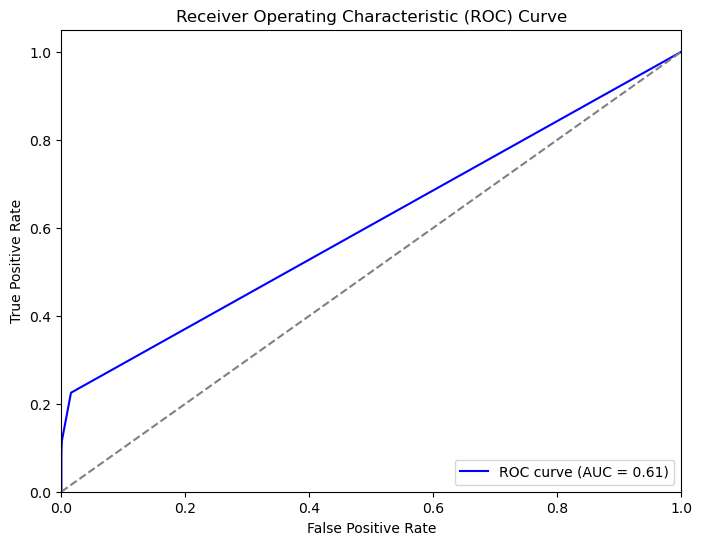


 AUC (Area Under the Curve): 0.6056047617130109


In [31]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
print("\n AUC (Area Under the Curve):", roc_auc)


In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Precision: 0.83
Recall: 0.09
F1-Score: 0.16


In [12]:
#Decision Tree

In [10]:
from sklearn import tree
model = tree.DecisionTreeClassifier(criterion="entropy")

In [11]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
cr = classification_report(y_test, y_pred)
print("\nClassification Report:",)
print (cr)
acc = accuracy_score(y_test,y_pred)
print("\nAccuracy:",acc)

Confusion Matrix:
[[165962    114]
 [   118    522]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.82      0.82      0.82       640

    accuracy                           1.00    166716
   macro avg       0.91      0.91      0.91    166716
weighted avg       1.00      1.00      1.00    166716


Accuracy: 0.9986084119100747


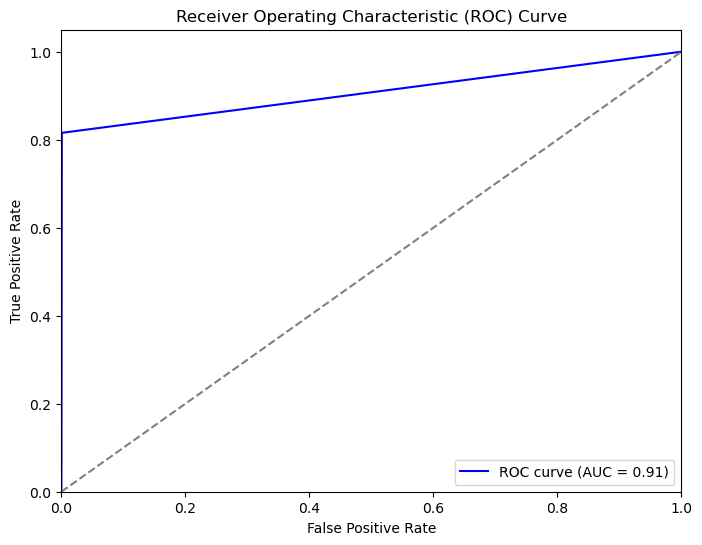


 AUC (Area Under the Curve): 0.9074692836412246


In [14]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
print("\n AUC (Area Under the Curve):", roc_auc)

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.82
Recall: 0.82
F1-Score: 0.82


In [13]:
#Feedforward Neural Network (Multilayer Perceptron - MLP)

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input

# Load dataset
df = pd.read_csv("fraudTest_feature_engineered1.csv")  # Replace with your actual CSV file

# Check data structure
print(df.head())  # Display first few rows

# Select features and target
X = df.drop(columns=['is_fraud']).to_numpy()  # Use all columns except target
y = df['is_fraud'].to_numpy()

# Check shape
print("X shape:", X.shape)  # Ensure correct dimensions

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get input dimension dynamically
input_dim = X.shape[1]

# Build the model
model = Sequential([
    Input(shape=(input_dim,)),  # Dynamically set input shape
    Dense(500, activation='relu'),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=100, verbose=1)

# Make a prediction
X_marks = np.array([[20] * input_dim])  # Ensure the test input matches the feature size
prediction = model.predict(X_marks)
print("Prediction:", prediction)


   Unnamed: 0            cc_num  merchant  category       amt  first  last  \
0           0  2291163933867244       319        10  0.000082    151   115   
1           1  3573030041201292       591        10  0.001267    163   457   
2           2  3598215285024754       611         5  0.001769     24   249   
3           3  3591919803438423       222         9  0.002594     42   457   
4           4  3526826139003047       292        13  0.000096    247   261   

   street  city  state  ...  amt_outlier  transaction_hour  transaction_day  \
0     341   157     39  ...            0                12                6   
1     354    16     43  ...            0                12                6   
2     865    61     33  ...            0                12                6   
3     320   764      8  ...            0                12                6   
4     548   247     21  ...            0                12                6   

   risky_city  user_fraud_count  user_avg_amt  gender_F 

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to binary class labels
y_pred = (y_pred_probs > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Compute classification report
cr = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(cr)

# Compute accuracy
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)


5210/5210 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step
Confusion Matrix:
[[166076      0]
 [   640      0]]


C:\Users\suma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.00      0.00      0.00       640

    accuracy                           1.00    166716
   macro avg       0.50      0.50      0.50    166716
weighted avg       0.99      1.00      0.99    166716


Accuracy: 0.9961611363036541


C:\Users\suma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\suma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


5210/5210 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step


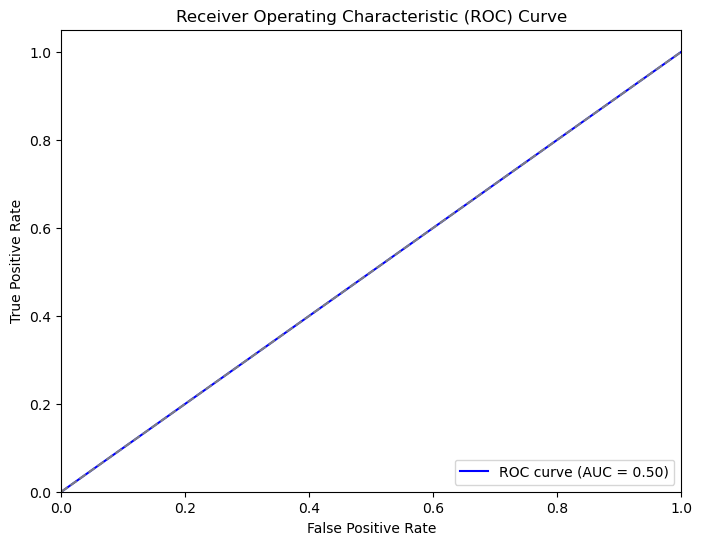


AUC (Area Under the Curve): 0.5


In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (fraud)
y_pred_probs = model.predict(X_test)[:, 0]  # Extract the first column

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print("\nAUC (Area Under the Curve):", roc_auc)


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Convert predicted probabilities to binary class labels
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

5210/5210 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step


C:\Users\suma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Precision: 0.00
Recall: 0.00
F1-Score: 0.00


In [1]:
#Random forest

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("fraudTest_feature_engineered1.csv")

# Separate features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

C:\Users\suma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
#2. Model Initialization and Training
from sklearn.ensemble import RandomForestClassifier

# Initialize and train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
#3. Making Predictions
# Predict on test data
y_pred = model.predict(X_test)

In [6]:
#4. Model Evaluation - Accuracy
from sklearn.metrics import accuracy_score
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 99.88%


In [7]:
#5. Confusion Matrix
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[166067      9]
 [   198    442]]


In [8]:
#6. Classification Report
from sklearn.metrics import classification_report

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.98      0.69      0.81       640

    accuracy                           1.00    166716
   macro avg       0.99      0.85      0.90    166716
weighted avg       1.00      1.00      1.00    166716



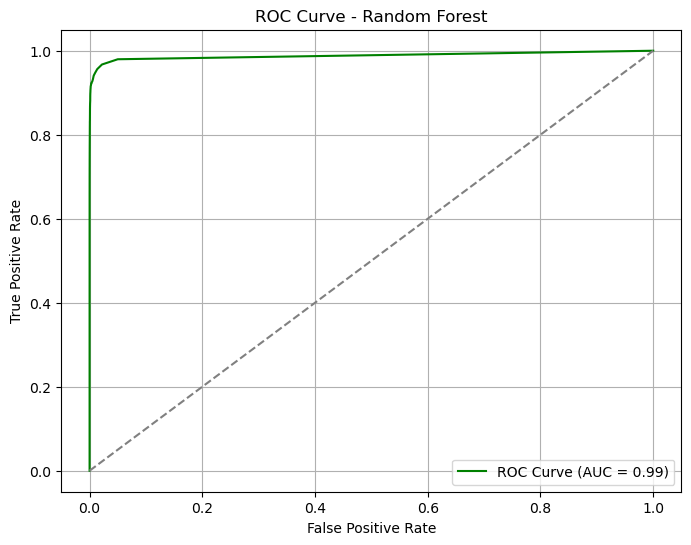

AUC Score: 0.99


In [9]:
#7. ROC Curve and AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"AUC Score: {roc_auc:.2f}")

In [10]:
#8. Precision, Recall, and F1-Score
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.98
Recall: 0.69
F1-Score: 0.81
